Task 1: Verify your Google Cloud environment setup, including capturing proof of your active cloud notebook instance or billing credit balance.

In [ ]:
import sys, platform, datetime

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Run timestamp (UTC):", datetime.datetime.utcnow())

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.153+-x86_64-with-glibc2.35
Run timestamp (UTC): 2026-10-09 03:24:27.112262


/tmp/ipykernel_104/2668407657.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("Run timestamp (UTC):", datetime.datetime.utcnow())


Task 2: Load the dataset into a Pandas DataFrame using the official ucimlrepo package or direct data retrieval methods linked to the UCI repository

In [ ]:
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo
import pandas as pd

air_quality = fetch_ucirepo(id=360)
df = air_quality.data.features.copy()

print("Shape:", df.shape)

Shape: (9357, 15)


Task 3: Use structural inspection methods (head(), info(), describe()) to analyze the dataset structure and examine feature distributions across sensor and meteorological variables.

In [ ]:
display(df.head())
df.info()
display(df.describe().T)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


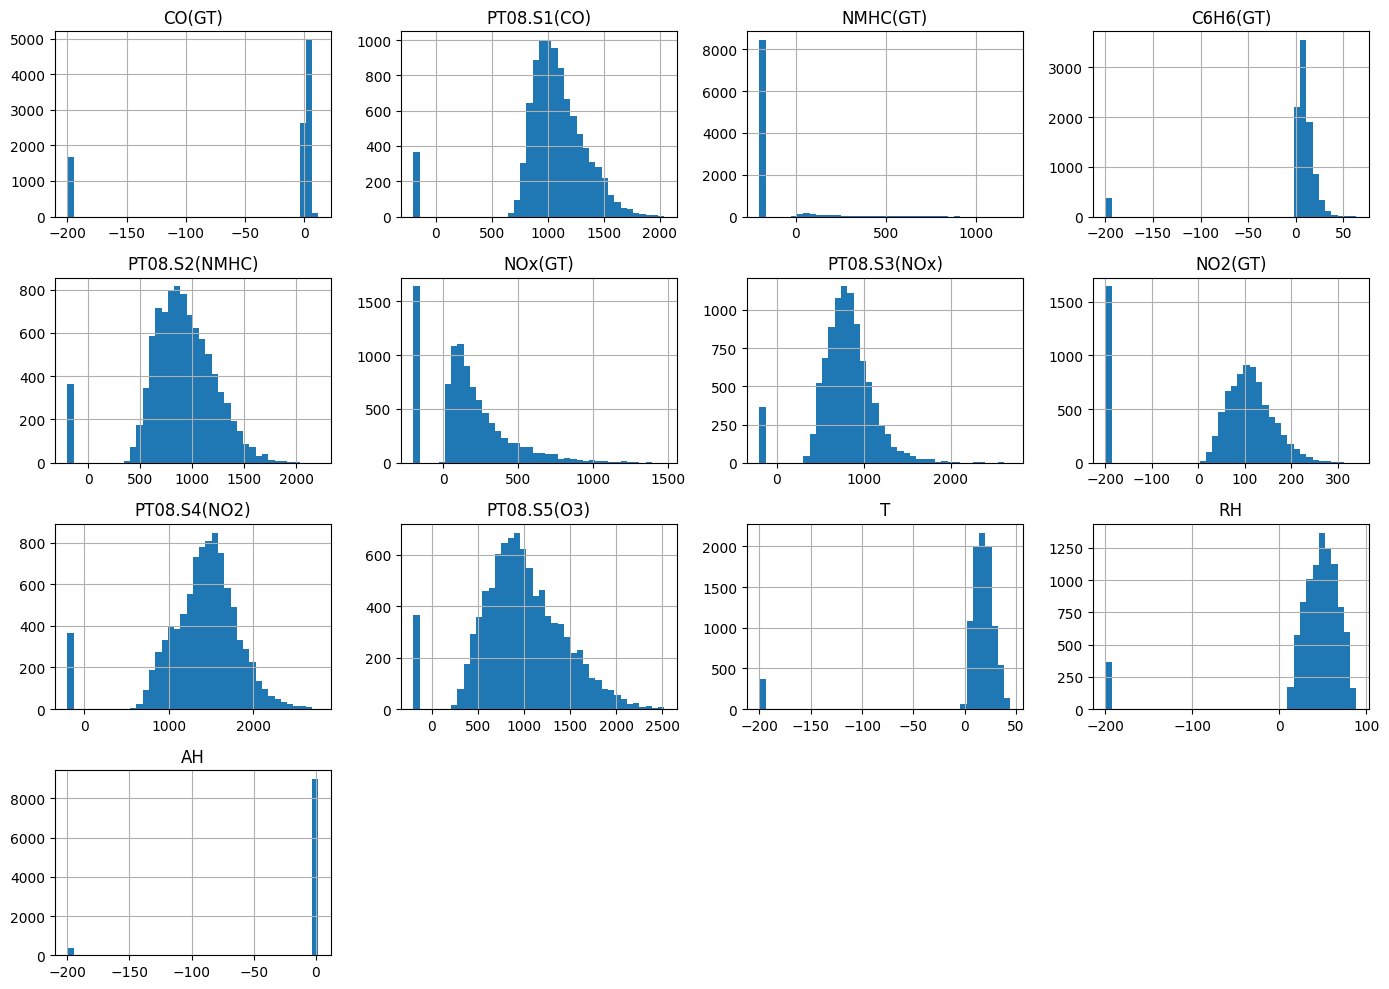

In [ ]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(bins=40, figsize=(14, 10))
plt.tight_layout()
plt.show()

Task 4: Identify and handle implicit missing data values (such as the standard -200 sentinel values present in the air quality dataset) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [ ]:
import numpy as np

df = df.replace(-200, np.nan)

missing = pd.DataFrame({
    "count": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(1)
}).sort_values("percent", ascending=False)

display(missing)

,count,percent
NMHC(GT),8443,90.2
CO(GT),1683,18.0
NOx(GT),1639,17.5
NO2(GT),1642,17.5
PT08.S2(NMHC),366,3.9
C6H6(GT),366,3.9
PT08.S1(CO),366,3.9
PT08.S5(O3),366,3.9
T,366,3.9
PT08.S3(NOx),366,3.9


In [ ]:
df = df.drop(columns=["NMHC(GT)"])


df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%m/%d/%Y %H:%M:%S")
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["dayofweek"] = df["datetime"].dt.dayofweek
df = df.drop(columns=["Date", "Time", "datetime"])


target = "CO(GT)"
df = df.dropna(subset=[target]).reset_index(drop=True)
print("Rows remaining:", len(df))

Rows remaining: 7674


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)

print(dict(zip(X_train.columns, imputer.statistics_.round(2))))

{'PT08.S1(CO)': np.float64(1076.0), 'C6H6(GT)': np.float64(8.6), 'PT08.S2(NMHC)': np.float64(922.0), 'NOx(GT)': np.float64(189.0), 'PT08.S3(NOx)': np.float64(794.0), 'NO2(GT)': np.float64(111.0), 'PT08.S4(NO2)': np.float64(1446.0), 'PT08.S5(O3)': np.float64(994.0), 'T': np.float64(16.8), 'RH': np.float64(49.4), 'AH': np.float64(0.96), 'hour': np.float64(12.0), 'month': np.float64(6.0), 'dayofweek': np.float64(3.0)}


Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and necessary encoding to categorical/temporal features.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = ["hour", "month", "dayofweek"]
num_cols = [c for c in X_train.columns if c not in cat_cols]
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Train shape:", X_train_prep.shape)
print("Test shape:", X_test_prep.shape)
print("Any NaNs left:", np.isnan(X_train_prep).any())

Numerical: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Categorical: ['hour', 'month', 'dayofweek']
Train shape: (6139, 54)
Test shape: (1535, 54)
Any NaNs left: False


Task 6: Train classification models to predict air quality categories using standard logistic/softmax regression and an SGDClassifier configured with custom loss functions and hyperparameters, evaluating convergence speed and performance.

In [ ]:
bins = pd.qcut(y_train, q=3, retbins=True)[1]
bins[0], bins[-1] = -np.inf, np.inf

y_train_cat = pd.cut(y_train, bins=bins, labels=[0, 1, 2]).astype(int)
y_test_cat  = pd.cut(y_test,  bins=bins, labels=[0, 1, 2]).astype(int)

print("Thresholds:", bins[1:-1])
print(y_train_cat.value_counts(normalize=True).sort_index())

Thresholds: [1.3 2.5]
CO(GT)
0    0.337840
1    0.345985
2    0.316175
Name: proportion, dtype: float64


In [ ]:
import time
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

t0 = time.time()
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_prep, y_train_cat)
logreg_time = time.time() - t0

pred = logreg.predict(X_test_prep)
print("Logistic accuracy:", round(accuracy_score(y_test_cat, pred), 4))
print("Iterations:", logreg.n_iter_, "| Time:", round(logreg_time, 3), "s")
print(classification_report(y_test_cat, pred, target_names=["Low", "Moderate", "High"]))
print(confusion_matrix(y_test_cat, pred))

Logistic accuracy: 0.8717
Iterations: [76] | Time: 1.421 s
              precision    recall  f1-score   support

         Low       0.91      0.89      0.90       549
    Moderate       0.80      0.85      0.83       534
        High       0.92      0.87      0.90       452

    accuracy                           0.87      1535
   macro avg       0.88      0.87      0.87      1535
weighted avg       0.87      0.87      0.87      1535

[[488  59   2]
 [ 47 456  31]
 [  2  56 394]]


In [ ]:
configs = {
    "log_loss (default lr)":         dict(loss="log_loss"),
    "hinge":                         dict(loss="hinge"),
    "modified_huber":                dict(loss="modified_huber"),
    "log_loss, constant lr 0.001":   dict(loss="log_loss", learning_rate="constant", eta0=0.001),
    "log_loss, constant lr 0.1":     dict(loss="log_loss", learning_rate="constant", eta0=0.1),
    "log_loss, alpha=0.01":          dict(loss="log_loss", alpha=0.01),
}

rows = []
for name, params in configs.items():
    t0 = time.time()
    clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42, **params)
    clf.fit(X_train_prep, y_train_cat)
    rows.append({
        "config": name,
        "epochs_to_stop": clf.n_iter_,
        "time_s": round(time.time() - t0, 3),
        "test_acc": round(accuracy_score(y_test_cat, clf.predict(X_test_prep)), 4),
    })

results = pd.DataFrame(rows)
display(results)

,config,epochs_to_stop,time_s,test_acc
0,log_loss (default lr),35,0.155,0.8632
1,hinge,66,0.137,0.8508
2,modified_huber,94,0.274,0.8554
3,"log_loss, constant lr 0.001",47,0.145,0.8554
4,"log_loss, constant lr 0.1",26,0.078,0.8502
5,"log_loss, alpha=0.01",10,0.050,0.8567


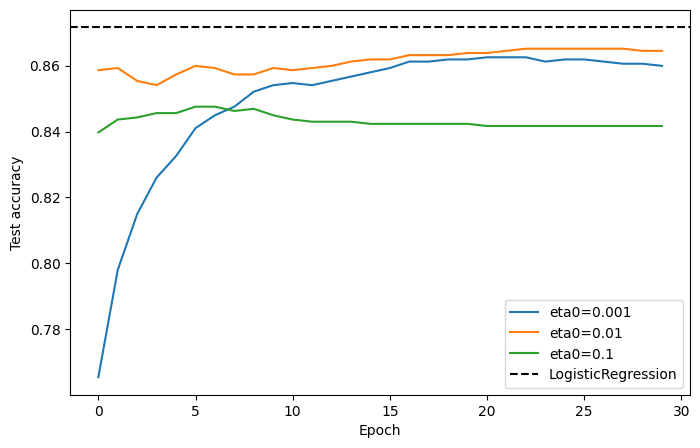

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for lr in [0.001, 0.01, 0.1]:
    clf = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=lr, random_state=42)
    accs = []
    for epoch in range(30):
        clf.partial_fit(X_train_prep, y_train_cat, classes=[0, 1, 2])
        accs.append(accuracy_score(y_test_cat, clf.predict(X_test_prep)))
    ax.plot(accs, label=f"eta0={lr}")

ax.axhline(accuracy_score(y_test_cat, pred), color="k", ls="--", label="LogisticRegression")
ax.set_xlabel("Epoch"); ax.set_ylabel("Test accuracy"); ax.legend()
plt.show()

Task 7: Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization parameter impacts feature coefficients and feature selection.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

feature_names = preprocessor.get_feature_names_out()

def score(model):
    p = model.predict(X_test_prep)
    return round(np.sqrt(mean_squared_error(y_test, p)), 4), round(r2_score(y_test, p), 4)

lin = LinearRegression().fit(X_train_prep, y_train)
print("Linear  RMSE, R2:", score(lin))

Linear  RMSE, R2: (np.float64(0.4268), 0.9126)


In [ ]:
alphas = np.logspace(-3, 1, 25)
rows, ridge_coefs, lasso_coefs = [], [], []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_prep, y_train)
    l = Lasso(alpha=a, max_iter=20000).fit(X_train_prep, y_train)
    ridge_coefs.append(r.coef_); lasso_coefs.append(l.coef_)
    rows.append({
        "alpha": round(a, 4),
        "ridge_rmse": score(r)[0], "ridge_r2": score(r)[1],
        "lasso_rmse": score(l)[0], "lasso_r2": score(l)[1],
        "lasso_zero_coefs": int((l.coef_ == 0).sum()),
    })

display(pd.DataFrame(rows))
ridge_coefs, lasso_coefs = np.array(ridge_coefs), np.array(lasso_coefs)

,alpha,ridge_rmse,ridge_r2,lasso_rmse,lasso_r2,lasso_zero_coefs
0,0.0010,0.4268,0.9126,0.4276,0.9122,11
1,0.0015,0.4268,0.9126,0.4295,0.9114,11
2,0.0022,0.4268,0.9126,0.4333,0.9098,14
3,0.0032,0.4268,0.9126,0.4391,0.9074,20
4,0.0046,0.4268,0.9126,0.4464,0.9043,28
5,0.0068,0.4268,0.9126,0.4570,0.8997,33
6,0.0100,0.4268,0.9126,0.4707,0.8936,39
7,0.0147,0.4268,0.9126,0.4873,0.8860,43
8,0.0215,0.4268,0.9126,0.4943,0.8827,47
9,0.0316,0.4268,0.9126,0.5030,0.8785,48


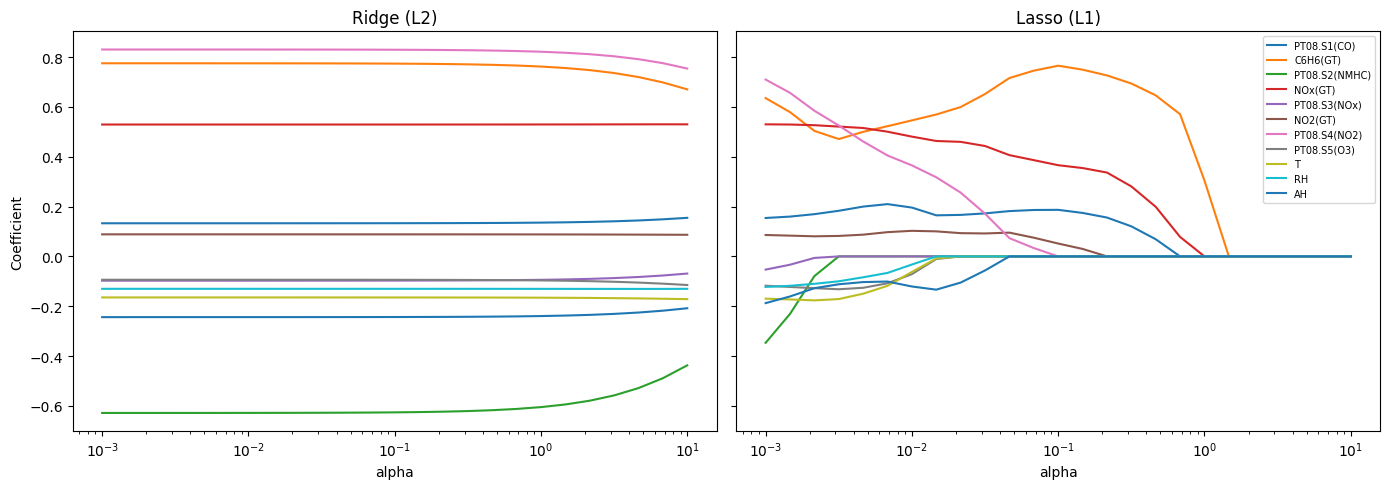

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, coefs, title in [(axes[0], ridge_coefs, "Ridge (L2)"), (axes[1], lasso_coefs, "Lasso (L1)")]:
    for i in range(11):                      # the 11 numerical features
        ax.plot(alphas, coefs[:, i], label=feature_names[i].replace("num__", ""))
    ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_title(title)
axes[0].set_ylabel("Coefficient"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge_cv = RidgeCV(alphas=alphas).fit(X_train_prep, y_train)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=20000).fit(X_train_prep, y_train)
print("Best Ridge alpha:", ridge_cv.alpha_, "->", score(ridge_cv))
print("Best Lasso alpha:", lasso_cv.alpha_, "->", score(lasso_cv))

coef = pd.Series(lasso_cv.coef_, index=feature_names)
print("Kept:", (coef != 0).sum(), "of", len(coef))
print(coef[coef != 0].sort_values(key=abs, ascending=False).head(10))

Best Ridge alpha: 1.467799267622069 -> (np.float64(0.4268), 0.9126)
Best Lasso alpha: 0.001 -> (np.float64(0.4276), 0.9122)
Kept: 43 of 54
num__PT08.S4(NO2)     0.710009
num__C6H6(GT)         0.635632
num__NOx(GT)          0.530308
cat__month_12         0.453306
cat__hour_20          0.382918
cat__hour_19          0.369329
num__PT08.S2(NMHC)   -0.346951
cat__hour_18          0.286087
cat__hour_3          -0.263312
cat__hour_21          0.244365
dtype: float64


Task 8: Provide a final documentation cell or appendix section containing a screenshot or export of your Google Cloud billing or resource utilization dashboard showing active credit consumption.

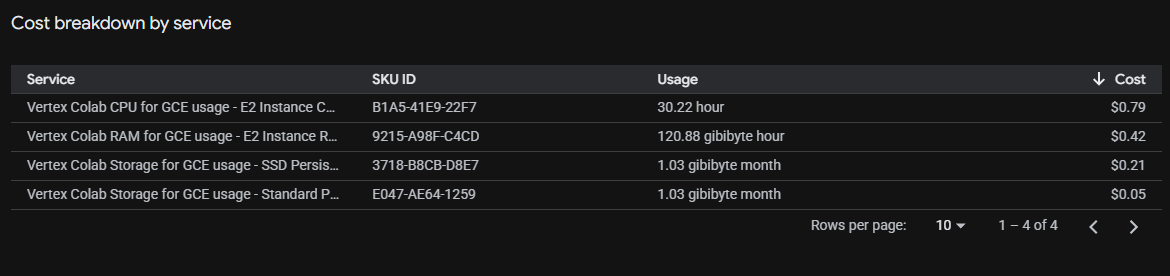